In [1]:
import pandas as pd
carstocks = pd.read_csv('../data/car_stocks.csv')
titanic = pd.read_csv('../data/titanic.csv')

titanic['age'] = titanic['age'].replace(['?'], [None]).astype('float')
titanic['fare'] = titanic['fare'].replace(['?'], [None]).astype('float')

In [2]:
s1 = titanic.groupby('sex')['age'].mean()
s1.index

Index(['female', 'male'], dtype='object', name='sex')

In [3]:
s2 = titanic.groupby(['pclass', 'sex'])['age'].mean()
s2.index

MultiIndex([(1, 'female'),
            (1,   'male'),
            (2, 'female'),
            (2,   'male'),
            (3, 'female'),
            (3,   'male')],
           names=['pclass', 'sex'])

In [5]:
titanic.groupby(['sex', 'age'])

In [9]:
state_pops = pd.read_csv('../data/state_pops.csv')
state_pops = state_pops.set_index('state')
state_pops.loc['AL']

,year,population
state,,
AL,2012,4817528.0
AL,2010,4785570.0
AL,2011,4801627.0
AL,2009,4757938.0
AL,2013,4833722.0
AL,2007,4672840.0
AL,2008,4718206.0
AL,2005,4569805.0
AL,2006,4628981.0


In [11]:
state_pops = pd.read_csv('../data/state_pops.csv')
df = state_pops.set_index(['state', 'year'])

MultiIndex([( 'AL', 2012),
            ( 'AL', 2010),
            ( 'AL', 2011),
            ( 'AL', 2009),
            ( 'AL', 2013),
            ( 'AL', 2007),
            ( 'AL', 2008),
            ( 'AL', 2005),
            ( 'AL', 2006),
            ( 'AL', 2004),
            ...
            ('USA', 2004),
            ('USA', 2005),
            ('USA', 2006),
            ('USA', 2007),
            ('USA', 2008),
            ('USA', 2013),
            ('USA', 2009),
            ('USA', 2010),
            ('USA', 2011),
            ('USA', 2012)],
           names=['state', 'year'], length=1272)

In [13]:
df.loc[('AL', 2012)]

population    4817528.0
Name: (AL, 2012), dtype: float64

In [14]:
df.sort_index().head(10) #Sorts both index levels in ascending or descending

population
state year            
AK    1990    553290.0
      1991    570193.0
      1992    588736.0
      1993    599434.0
      1994    603308.0
      1995    604412.0
      1996    608569.0
      1997    612968.0
      1998    619933.0
      1999    624779.0

In [15]:
#to sort just one index
df.sort_index(level=1).head(10) #level 0, 1

,,population
state,year,
AK,1990,553290.0
AL,1990,4050055.0
AR,1990,2356586.0
AZ,1990,3684097.0
CA,1990,29959515.0
CO,1990,3307618.0
CT,1990,3291967.0
DC,1990,605321.0
DE,1990,669567.0


In [18]:
#to sort just one index
df.sort_index(level=[0, 1], ascending=[False, True]) #level 0 acsending False, 1 ascending True

population
state year            
WY    1990    453690.0
      1991    459260.0
      1992    466251.0
      1993    473081.0
      1994    480283.0
...                ...
AK    2009    698895.0
      2010    713868.0
      2011    723375.0
      2012    730307.0
      2013    735132.0

[1272 rows x 1 columns]

In [19]:
df.loc['NV']

,population
year,
2012,2754354.0
2011,2717951.0
2010,2703230.0
2013,2790136.0
2009,2684665.0
2007,2601072.0
2008,2653630.0
2005,2432143.0
2006,2522658.0


In [21]:
df.loc['NV'].loc[1990]

population    1220695.0
Name: 1990, dtype: float64

In [32]:
dfs = df.sort_index()
dfs.loc['AK': 'CA']

population
state year            
AK    1990    553290.0
      1991    570193.0
      1992    588736.0
      1993    599434.0
      1994    603308.0
...                ...
CA    2009  36961229.0
      2010  37333601.0
      2011  37668681.0
      2012  37999878.0
      2013  38332521.0

[120 rows x 1 columns]

In [36]:
dfs.loc[('MT', 1992)]

population    825770.0
Name: (MT, 1992), dtype: float64

In [34]:
dfs.loc[('MT', 1990):('MT', 1995)]

population
state year            
MT    1990    800204.0
      1991    809680.0
      1992    825770.0
      1993    844761.0
      1994    861306.0
      1995    876553.0

In [37]:
#All with 1990
dfs.loc[:, 1990, :] #All level 0 values

,population
state,
AK,553290.0
AL,4050055.0
AR,2356586.0
AZ,3684097.0
CA,29959515.0
CO,3307618.0
CT,3291967.0
DC,605321.0
DE,669567.0


In [38]:
dfs.loc[:, [1990, 1991], :] #All level 0 values

population
state year            
AK    1990    553290.0
      1991    570193.0
AL    1990   4050055.0
      1991   4099156.0
AR    1990   2356586.0
...                ...
WI    1991   4964343.0
WV    1990   1792548.0
      1991   1798735.0
WY    1990    453690.0
      1991    459260.0

[106 rows x 1 columns]

In [39]:
dfs.loc[slice(None), [1990, 1991], :] #All level 0 values

population
state year            
AK    1990    553290.0
      1991    570193.0
AL    1990   4050055.0
      1991   4099156.0
AR    1990   2356586.0
...                ...
WI    1991   4964343.0
WV    1990   1792548.0
      1991   1798735.0
WY    1990    453690.0
      1991    459260.0

[106 rows x 1 columns]

# XS

In [40]:
dfs.xs(2013, level='year')

,population
state,
AK,735132.0
AL,4833722.0
AR,2959373.0
AZ,6626624.0
CA,38332521.0
CO,5268367.0
CT,3596080.0
DC,646449.0
DE,925749.0


In [42]:
dfs.xs(2013, level='year')

,population
state,
AK,735132.0
AL,4833722.0
AR,2959373.0
AZ,6626624.0
CA,38332521.0
CO,5268367.0
CT,3596080.0
DC,646449.0
DE,925749.0


In [43]:
dfs.xs(2013, level=1)

,population
state,
AK,735132.0
AL,4833722.0
AR,2959373.0
AZ,6626624.0
CA,38332521.0
CO,5268367.0
CT,3596080.0
DC,646449.0
DE,925749.0


In [44]:
dfs.xs('CO')

,population
year,
1990,3307618.0
1991,3387119.0
1992,3495939.0
1993,3613734.0
1994,3724168.0
1995,3826653.0
1996,3919972.0
1997,4018293.0
1998,4116639.0


In [46]:
#GET level VALUES
df.index

MultiIndex([( 'AL', 2012),
            ( 'AL', 2010),
            ( 'AL', 2011),
            ( 'AL', 2009),
            ( 'AL', 2013),
            ( 'AL', 2007),
            ( 'AL', 2008),
            ( 'AL', 2005),
            ( 'AL', 2006),
            ( 'AL', 2004),
            ...
            ('USA', 2004),
            ('USA', 2005),
            ('USA', 2006),
            ('USA', 2007),
            ('USA', 2008),
            ('USA', 2013),
            ('USA', 2009),
            ('USA', 2010),
            ('USA', 2011),
            ('USA', 2012)],
           names=['state', 'year'], length=1272)

In [47]:
df.index.levels

FrozenList([['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'USA', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY'], [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013]])

In [48]:
df.index.get_level_values(0)

Index(['AL', 'AL', 'AL', 'AL', 'AL', 'AL', 'AL', 'AL', 'AL', 'AL',
       ...
       'USA', 'USA', 'USA', 'USA', 'USA', 'USA', 'USA', 'USA', 'USA', 'USA'],
      dtype='object', name='state', length=1272)

In [49]:
df.index.get_level_values(1)

Index([2012, 2010, 2011, 2009, 2013, 2007, 2008, 2005, 2006, 2004,
       ...
       2004, 2005, 2006, 2007, 2008, 2013, 2009, 2010, 2011, 2012],
      dtype='int64', name='year', length=1272)

In [51]:
even_years = df.index.get_level_values(1) % 2 == 0

In [53]:
len(even_years)

1272

In [54]:
df[even_years]

population
state year             
AL    2012    4817528.0
      2010    4785570.0
      2008    4718206.0
      2006    4628981.0
      2004    4530729.0
...                 ...
USA   2004  292805298.0
      2006  298379912.0
      2008  304093966.0
      2010  309326295.0
      2012  313873685.0

[636 rows x 1 columns]

In [58]:
df[df.index.get_level_values(0).str[1] == 'A'] #ends with a

population
state year            
CA    2012  37999878.0
      2011  37668681.0
      2010  37333601.0
      2013  38332521.0
      2009  36961229.0
...                ...
WA    2013   6971406.0
      2009   6667426.0
      2010   6742256.0
      2011   6821481.0
      2012   6895318.0

[192 rows x 1 columns]

In [65]:
titan = titanic.groupby(['pclass', 'sex']).mean(numeric_only=True)
titan.loc[(2,   'male')]['age']

np.float64(30.815400632911395)

In [72]:
#Hierarchical column names
titan = titanic.groupby('sex').agg({
    "age": ['min', 'max', 'mean'],
    "fare": ['min', 'max', 'mean'],
    'survived': ['mean']
})
print(titan.index)
titan

Index(['female', 'male'], dtype='object', name='sex')


age                   fare                       survived
           min   max       mean   min       max       mean      mean
sex                                                                 
female  0.1667  76.0  28.687071  6.75  512.3292  46.198097  0.727468
male    0.3333  80.0  30.585233  0.00  512.3292  26.154601  0.190985

In [68]:
titan.columns

MultiIndex([(     'age',  'min'),
            (     'age',  'max'),
            (     'age', 'mean'),
            (    'fare',  'min'),
            (    'fare',  'max'),
            (    'fare', 'mean'),
            ('survived', 'mean')],
           )

In [74]:
titan[('age',  'min')]

sex
female    0.1667
male      0.3333
Name: (age, min), dtype: float64

In [76]:
#Stack Unstack  turns index to columns  defaults to innermost layer
df.unstack()

population                                                      \
year          1990         1991         1992         1993         1994   
state                                                                    
AK        553290.0     570193.0     588736.0     599434.0     603308.0   
AL       4050055.0    4099156.0    4154014.0    4214202.0    4260229.0   
AR       2356586.0    2383144.0    2415984.0    2456303.0    2494019.0   
AZ       3684097.0    3788576.0    3915740.0    4065440.0    4245089.0   
CA      29959515.0   30470736.0   30974659.0   31274928.0   31484435.0   
CO       3307618.0    3387119.0    3495939.0    3613734.0    3724168.0   
CT       3291967.0    3302895.0    3300712.0    3309175.0    3316121.0   
DC        605321.0     600870.0     597567.0     595302.0     589240.0   
DE        669567.0     683080.0     694927.0     706378.0     717545.0   
FL      13033307.0   13369798.0   13650553.0   13927185.0   14239444.0   
GA       6512602.0    6653005.0    6817203.0    6978240.0    7157165.0   
HI       1113491.0    1136754.0    1158613.0    1172838.0    1187536.0   
IA       2781018.0    2797613.0    2818401.0    2836972.0    2850746.0   
ID       1012384.0    1041316.0    1071685.0    1108768.0    1145140.0   
IL      11453316.0   11568964.0   11694184.0   11809579.0   11912585.0   
IN       5557798.0    5616388.0    5674547.0    5739019.0    5793526.0   
KS       2481349.0    2498722.0    2532395.0    2556547.0    2580513.0   
KY       3694048.0    3722328.0    3765469.0    3812206.0    3849088.0   
LA       4221532.0    4253279.0    4293003.0    4316428.0    4347481.0   
MA       6022639.0    6018470.0    6028709.0    6060569.0    6095241.0   
MD       4799770.0    4867641.0    4923369.0    4971889.0    5023060.0   
ME       1231719.0    1237081.0    1238508.0    1242302.0    1242662.0   
MI       9311319.0    9400446.0    9479065.0    9540114.0    9597737.0   
MN       4389857.0    4440859.0    4495572.0    4555956.0    4610355.0   
MO       5128880.0    5170800.0    5217101.0    5271175.0    5324497.0   
MS       2578897.0    2598733.0    2623734.0    2655100.0    2688992.0   
MT        800204.0     809680.0     825770.0     844761.0     861306.0   
NC       6664016.0    6784280.0    6897214.0    7042818.0    7187398.0   
ND        637685.0     635753.0     638223.0     641216.0     644806.0   
NE       1581660.0    1595919.0    1611687.0    1625590.0    1639041.0   
NH       1112384.0    1109929.0    1117785.0    1129458.0    1142561.0   
NJ       7762963.0    7814676.0    7880508.0    7948915.0    8014306.0   
NM       1521574.0    1555305.0    1595442.0    1636453.0    1682398.0   
NV       1220695.0    1296172.0    1351367.0    1411215.0    1499298.0   
NY      18020784.0   18122510.0   18246653.0   18374954.0   18459470.0   
OH      10864162.0   10945762.0   11029431.0   11101140.0   11152455.0   
OK       3148825.0    3175440.0    3220517.0    3252285.0    3280940.0   
OR       2860375.0    2928507.0    2991755.0    3060367.0    3121264.0   
PA      11903299.0   11982164.0   12049450.0   12119724.0   12166050.0   
PR             NaN          NaN          NaN          NaN          NaN   
RI       1005995.0    1010649.0    1012581.0    1015113.0    1015960.0   
SC       3501155.0    3570404.0    3620464.0    3663314.0    3705397.0   
SD        697101.0     703669.0     712801.0     722160.0     730790.0   
TN       4894492.0    4966587.0    5049742.0    5137584.0    5231438.0   
TX      17056755.0   17398005.0   17759738.0   18161612.0   18564062.0   
USA    249622814.0  252980942.0  256514231.0  259918595.0  263125826.0   
UT       1731223.0    1779780.0    1836799.0    1898404.0    1960446.0   
VA       6216884.0    6301217.0    6414307.0    6509630.0    6593139.0   
VT        564798.0     568606.0     572751.0     577748.0     583836.0   
WA       4903043.0    5025624.0    5160757.0    5278842.0    5375161.0   
WI       4904562.0    4964343.0    5025398.0    5084889.0    5133678.0   
WV       179

In [77]:
df.unstack(level='state')

population                                                          \
state         AK         AL         AR         AZ          CA         CO   
year                                                                       
1990    553290.0  4050055.0  2356586.0  3684097.0  29959515.0  3307618.0   
1991    570193.0  4099156.0  2383144.0  3788576.0  30470736.0  3387119.0   
1992    588736.0  4154014.0  2415984.0  3915740.0  30974659.0  3495939.0   
1993    599434.0  4214202.0  2456303.0  4065440.0  31274928.0  3613734.0   
1994    603308.0  4260229.0  2494019.0  4245089.0  31484435.0  3724168.0   
1995    604412.0  4296800.0  2535399.0  4432499.0  31696582.0  3826653.0   
1996    608569.0  4331103.0  2572109.0  4586940.0  32018834.0  3919972.0   
1997    612968.0  4367935.0  2601091.0  4736990.0  32486010.0  4018293.0   
1998    619933.0  4404701.0  2626289.0  4883342.0  32987675.0  4116639.0   
1999    624779.0  4430141.0  2651860.0  5023823.0  33499204.0  4226018.0   
2000    627963.0  4452173.0  2678588.0  5160586.0  33987977.0  4326921.0   
2001    633714.0  4467634.0  2691571.0  5273477.0  34479458.0  4425687.0   
2002    642337.0  4480089.0  2705927.0  5396255.0  34871843.0  4490406.0   
2003    648414.0  4503491.0  2724816.0  5510364.0  35253159.0  4528732.0   
2004    659286.0  4530729.0  2749686.0  5652404.0  35574576.0  4575013.0   
2005    666946.0  4569805.0  2781097.0  5839077.0  35827943.0  4631888.0   
2006    675302.0  4628981.0  2821761.0  6029141.0  36021202.0  4720423.0   
2007    680300.0  4672840.0  2848650.0  6167681.0  36250311.0  4803868.0   
2008    687455.0  4718206.0  2874554.0  6280362.0  36604337.0  4889730.0   
2009    698895.0  4757938.0  2896843.0  6343154.0  36961229.0  4972195.0   
2010    713868.0  4785570.0  2922280.0  6408790.0  37333601.0  5048196.0   
2011    723375.0  4801627.0  2938506.0  6468796.0  37668681.0  5118400.0   
2012    730307.0  4817528.0  2949828.0  6551149.0  37999878.0  5189458.0   
2013    735132.0  4833722.0  2959373.0  6626624.0  38332521.0  5268367.0   

                                                  ...                         \
state         CT        DC        DE          FL  ...         TN          TX   
year                                              ...                          
1990   3291967.0  605321.0  669567.0  13033307.0  ...  4894492.0  17056755.0   
1991   3302895.0  600870.0  683080.0  13369798.0  ...  4966587.0  17398005.0   
1992   3300712.0  597567.0  694927.0  13650553.0  ...  5049742.0  17759738.0   
1993   3309175.0  595302.0  706378.0  13927185.0  ...  5137584.0  18161612.0   
1994   3316121.0  589240.0  717545.0  14239444.0  ...  5231438.0  18564062.0   
1995   3324144.0  580519.0  729735.0  14537875.0  ...  5326936.0  18958751.0   
1996   3336685.0  572379.0  740978.0  14853360.0  ...  5416643.0  19340342.0   
1997   3349348.0  567739.0  751487.0  15186304.0  ...  5499233.0  19740317.0   
1998   3365352.0  565232.0  763335.0  15486559.0  ...  5570045.0  20157531.0   
1999   3386401.0  570220.0  774990.0  15759421.0  ...  5638706.0  20558220.0   
2000   3411777.0  572046.0  786373.0  16047515.0  ...  5703719.0  20944499.0   
2001   3432835.0  574504.0  795699.0  16356966.0  ...  5750789.0  21319622.0   
2002   3458749.0  573158.0  806169.0  16689370.0  ...  5795918.0  21690325.0   
2003   3484336.0  568502.0  818003.0  17004085.0  ...  5847812.0  22030931.0   
2004   3496094.0  567754.0  830803.0  17415318.0  ...  5910809.0  22394023.0   
2005   3506956.0  567136.0  845150.0  17842038.0  ...  5991057.0  22778123.0   
2006   3517460.0  570681.0  859268.0  18166990.0  ...  6088766.0  23359580.0   
2007   3527270.0  574404.0  871749.0  18367842.0  ...  6175727.0  23831983.0   
2008   3545579.0  580236.0  883874.0  18527305.0  ...  6247411.0  24309039.0   
2009   3561807.0  592228.0  891730.0  18652644.0  ...  6306019.0  24801761.0   
2010   3579210.0  605125.0  899711.0  18846054.0  ...  6356683.0  25245178.0   
2011   3588948.0  619624.0  90798

In [79]:
df_unstack = df.unstack()
df_unstack.stack(future_stack=True)

population
state year            
AK    1990    553290.0
      1991    570193.0
      1992    588736.0
      1993    599434.0
      1994    603308.0
...                ...
WY    2009    559851.0
      2010    564222.0
      2011    567329.0
      2012    576626.0
      2013    582658.0

[1272 rows x 1 columns]

In [81]:
#Plotting with unstack
age = titanic.groupby(['pclass', 'sex'])['age'].mean(numeric_only=True)
age

pclass  sex   
1       female    37.037594
        male      41.029250
2       female    27.499191
        male      30.815401
3       female    22.185307
        male      25.962273
Name: age, dtype: float64

<Axes: xlabel='pclass,sex'>

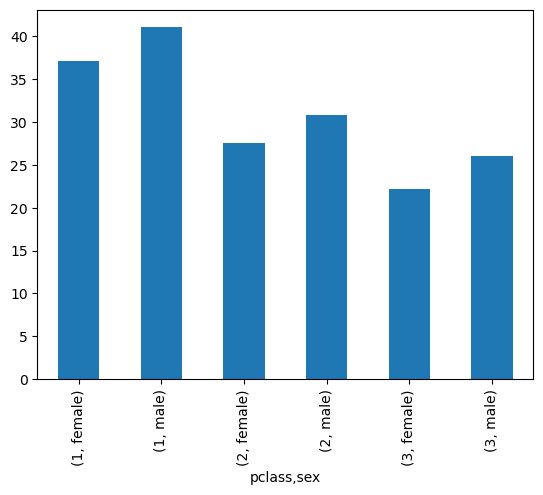

In [82]:
age.plot(kind='bar')

pclass  sex   
1       female    37.037594
        male      41.029250
2       female    27.499191
        male      30.815401
3       female    22.185307
        male      25.962273
Name: age, dtype: float64
sex        female       male
pclass                      
1       37.037594  41.029250
2       27.499191  30.815401
3       22.185307  25.962273


<Axes: xlabel='pclass'>

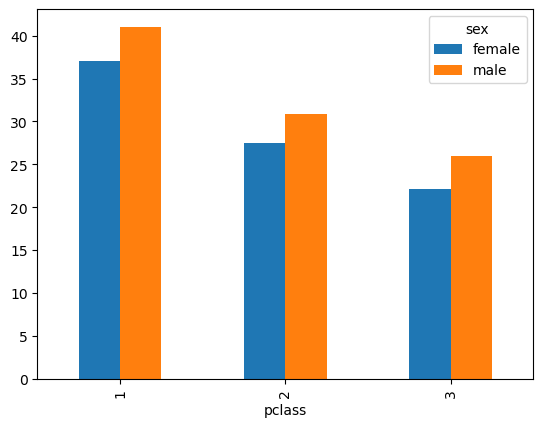

In [84]:
print(age)
print(age.unstack())
age.unstack().plot(kind='bar')

pclass  sex   
1       female    37.037594
        male      41.029250
2       female    27.499191
        male      30.815401
3       female    22.185307
        male      25.962273
Name: age, dtype: float64
pclass          1          2          3
sex                                    
female  37.037594  27.499191  22.185307
male    41.029250  30.815401  25.962273


<Axes: xlabel='sex'>

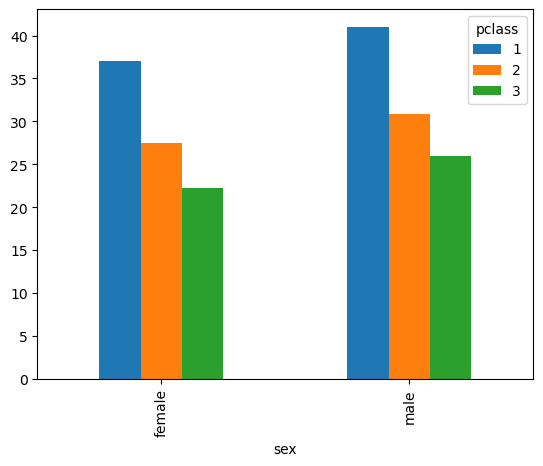

In [85]:
print(age)
print(age.unstack(level='pclass'))
age.unstack(level='pclass').plot(kind='bar')

<Axes: xlabel='sex'>

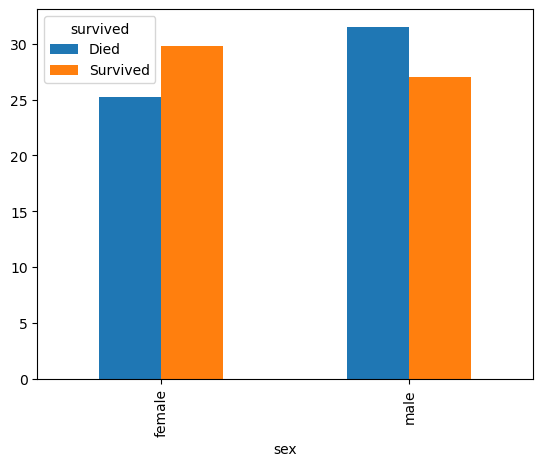

In [89]:
sevivors = titanic.groupby(['sex', 'survived'])['age'].mean().rename({0: "Died", 1: 'Survived'})
sevivors.unstack().plot(kind='bar')

In [92]:
#Group by index
df.groupby(level=1).sum()

,population
year,
1990,499245628.0
1991,505961884.0
1992,513028462.0
1993,519837190.0
1994,526251652.0
1995,532556806.0
1996,538788582.0
1997,545293864.0
1998,551708232.0


In [93]:
df.groupby(level=0).min() #df.groupby(level=[1,0]).min()
#df.groupby('year').min()

,population
state,
AK,553290.0
AL,4050055.0
AR,2356586.0
AZ,3684097.0
CA,29959515.0
CO,3307618.0
CT,3291967.0
DC,565232.0
DE,669567.0
